# S6-4 コーラブル債とOAS

## 学習目標

- コーラブル債（callable bond）を「ストレート債 − コールオプション」に分解し、
  発行体がコールを持つことがなぜ投資家にとって不利（＝利回りが上乗せされる）かを
  数式と価格で説明できる
- Hull-White 三項ツリー（S5-3 で構築したもの）上で、後退帰納法（backward induction）
  により行使判定を1ノードずつ織り込んだコーラブル債評価器をスクラッチ実装できる
- OAS（option-adjusted spread、オプション調整後スプレッド）の定義を述べ、ツリー割引に
  加える一定スプレッドの逆算として OAS ソルバーを実装できる
- Zスプレッド（zero-volatility spread）と OAS の差がオプションコストに一致することを、
  分解表として数値で示せる
- 金利を平行に動かして実効デュレーション（effective duration）を測り、コーラブル債の
  負のコンベクシティ（negative convexity）を可視化し、MBS との共通点を論じられる
- コール行使境界（exercise boundary）を短期金利平面上に描き、「金利が下がるとコール
  される」という直観を数値で裏づけられる

## 実務での位置づけ（ファンドはどう稼ぐか）

コーラブル債は、発行体が「ストレート債＋投資家に売ったコールオプション」を組み合わせて資金調達する商品です。発行体（銀行・事業法人）は借り換えの柔軟性を得る対価としてクーポンを上乗せし、その上乗せ分をデスクがオプションとして値付けします。バイサイドから見ると、コーラブル債は同年限のストレート債より高い利回り（OAS）が乗った投資対象で、運用会社・保険は「オプションを売って得た利回りの上乗せ」をキャリーとして取りにいきます。ここで実装した後退帰納法の評価器と OAS ソルバーは、その上乗せが本当に割安・割高かを判定する道具で、Zスプレッドと OAS の差＝オプションコストの分解は、利回りのうちどれだけが信用・流動性で、どれだけがオプション対価かを切り分けます。

OAS 投資の勝ち筋は、市場が付けた OAS が内包ボラ・行使モデルから見て割高な銘柄を買い、割安な銘柄を売り、金利リスクを実効デュレーションでヘッジしてキャリーとスプレッド収束を取ることです。ここで可視化した負のコンベクシティが、この戦略の最大の難所です。金利が下がると発行体がコールし値上がり益が頭打ちになり、上がると残存が延びて損失が膨らむため、実効デュレーションが金利水準で動き、静的なヘッジでは取りこぼします。デスクはガンマ・ベガのリスクをスワップションで動的にヘッジし、そのヘッジコストと OAS のキャリーの綱引きで損益が決まります。同じ負のコンベクシティは MBS（S8）でも中心論点で、コーラブルはその最小構成の練習台になります。

コール行使境界を短期金利平面に描く作業は、リスク管理の実務そのものです。「金利が下がるとコールされる」直観を数値の境界として持つことで、どの金利シナリオで残存・デュレーションが跳ねるかをシナリオ分析（S3）に載せられます。評価に使う OAS は割引に加える一定スプレッドとして逆算するので、金利モデルとボラの前提に強く依存します。自作の Hull-White ツリーを QuantLib の CallableFixedRateBond と数セント以内で突合するのは、この前提依存の評価がベンチマークと整合することを担保し、モデルバリデーションの承認に載せるためです。


## 理論

### コーラブル債＝ストレート債−コールオプション

コーラブル債は、発行体が定められた期日にあらかじめ決めた価格（コール価格 $K$、多くは
額面）で買い戻す権利を持つ債券である。投資家の立場では、同じクーポン・満期の
ストレート債（option-free bond）を保有しつつ、発行体にコールオプションを売っている
のと同じである。したがって価格は

$$
P_{\text{callable}} = P_{\text{straight}} - V_{\text{call}}
$$

と分解できる。$V_{\text{call}}\ge 0$ なので、コーラブル債はつねにストレート債より安い。
発行体は金利が下がったとき（＝債券価格が上がったとき）に低金利で借り換えるために
コールする。投資家はこの「値上がり益を取り上げられるリスク」の対価として、より高い
利回り、すなわちオプションコスト（option cost）だけ上乗せされたスプレッドを受け取る。

### ツリー上の後退帰納法（1ノードずつ）

コールオプションはバミューダ型（複数の行使日）で、経路依存かつ早期行使を伴うため、
解析解はない。格子モデルで後退帰納法により評価する。S5-3 で組んだ Hull-White 三項
ツリーの各節点 $(i,j)$ には短期金利 $r_{i,j}=\alpha_i+j\Delta x$ が付いている。満期で
額面＋最終クーポンを置き、時間をさかのぼりながら1段ずつ次を評価する。

節点 $(i,j)$ での継続価値（continuation value、コールしないで持ち続けたときの価値）は、
1段先の3つの子節点の期待値を割り引いたものにその時点のクーポン $c$ を足したもの:

$$
H_{i,j} = c + e^{-(r_{i,j}+s)\,\Delta t}\bigl(p_u V_{i+1,k+1} + p_m V_{i+1,k} + p_d V_{i+1,k-1}\bigr)
$$

ここで $s$ は割引に加える一定スプレッド（後述の OAS）、$p_u,p_m,p_d$ と中心 $k$ は
三項ツリーの分枝確率である。コール日 $i$ では、発行体は自分の価値（＝投資家の受取）を
最小化するように行動するので、その節点の債券価値は

$$
V_{i,j} = \min\bigl(H_{i,j},\; K + c\bigr)
$$

となる（$K$ はクーポン込みでない清算価格。ここではコール日＝クーポン日とし、経過利子は
ゼロなので受取は $K+c$）。コール日でない節点では $V_{i,j}=H_{i,j}$。この $\min$ を
1ノードずつ全節点に適用しながら根まで戻すと、根の値 $V_{0,0}$ がコーラブル債の現在価値
になる。$\min$ を外して素通しすればストレート債、$\min$ を有効にすればコーラブル債で、
両者の差が $V_{\text{call}}$ を与える。

### OAS の定義と解釈

市場で観測されるコーラブル債の価格 $P_{\text{mkt}}$ は、無裁定モデルが吐く理論価格とは
一般にずれる。信用・流動性・モデル誤差などがまとめてスプレッドとして残るからである。
OAS（オプション調整後スプレッド）は、ツリーの各節点の割引金利に一定量 $s$ を足したとき、
モデル価格が市場価格に一致する $s$ として定義する。

$$
P_{\text{model}}(s=\text{OAS}) = P_{\text{mkt}}
$$

「オプション調整後」とは、後退帰納法の中でコール（オプション行使）を織り込んだうえで
残るスプレッド、という意味である。オプション価値を価格から取り除いた後の、純粋な
上乗せ利回りを測る。OAS が大きいほど、オプション要因を除いてもなお割安（高利回り）と
解釈できるので、コーラブル債・MBS の相対価値指標として使われる。

### Zスプレッドとの差＝オプションコスト

Zスプレッド（zero-volatility spread）は、ボラティリティをゼロとみなし（＝オプションを
無視し）、約定どおりのキャッシュフローを満期まで割り引いて市場価格に一致させる一定
スプレッドである。

$$
P_{\text{mkt}} = \sum_k \text{CF}_k \, D(t_k)\, e^{-z\,t_k}, \qquad z=\text{Zスプレッド}
$$

Zスプレッドはコールを一切考えないので、オプション価値のぶんだけ余計に高い（コール
されうる不利を、すべてスプレッドに押し込めて表現する）。一方 OAS はオプションを別建てで
評価してから残差を測る。両者の差が、スプレッド換算のオプションコストである。

$$
\boxed{\;\text{オプションコスト} = \text{Zスプレッド} - \text{OAS}\;}
$$

コーラブル債では投資家がオプションを売っているのでこの差は正になる（プッタブル債なら
逆符号）。この分解は「割安さ（OAS）」と「オプションの重さ（オプションコスト）」を
分けて見るための実務の基本語彙である。

### 負のコンベクシティと実効デュレーション

早期行使のある債券は、キャッシュフロー自体が金利水準に依存するので、解析的な
デュレーションは使えない。カーブを平行に $\pm\Delta y$ 動かして再評価し、数値微分で
実効デュレーション（effective duration）を測る。

$$
D_{\text{eff}} = \frac{P_{-\Delta y}-P_{+\Delta y}}{2\,P_0\,\Delta y}, \qquad
C_{\text{eff}} = \frac{P_{+\Delta y}+P_{-\Delta y}-2P_0}{P_0\,\Delta y^2}
$$

ストレート債は価格・利回り曲線が下に凸（正のコンベクシティ）で、金利が下がるほど
デュレーションは伸びる。コーラブル債は、金利が下がるとコールされて価格が $K$ 付近で
頭打ちになるため、価格・利回り曲線が上に凸に反り、金利低下局面でデュレーションが
逆に縮む。これが負のコンベクシティ（$C_{\text{eff}}<0$）であり、$P=P_{\text{straight}}-V_{\text{call}}$
の右辺でコールオプションのガンマ（正）が引かれることに対応する。同じ現象は住宅ローンの
期限前償還オプションを内包する MBS でも起きる（実データ適用で論じる）。

### コール行使境界

各コール日で、継続価値 $H$ とコール価格 $K$ の大小が入れ替わる短期金利 $r^\ast$ を
コール行使境界（exercise boundary）と呼ぶ。継続価値は金利が下がるほど大きい（将来
キャッシュフローの割引が緩む）ので、$r<r^\ast$ でコール、$r>r^\ast$ で継続となる。
境界を時間軸に並べると、「いつ・どの金利水準でコールされるか」の地図になる。

## スクラッチ実装

S5-3 の `HullWhiteTree`（前向き帰納で $\alpha_i,\,Q_{i,j}$ を作り、後退帰納で ZCB を
評価する）をそのまま再掲し、その上に「コーラブル債の後退帰納評価」「OAS ソルバー」
「Zスプレッドソルバー」を積む。ツリー本体は変更しない——コール条項は評価側の
$\min$ 判定だけで表せる、という分離が要点である。

### 使用する自作クラス・関数

| クラス／関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `HullWhiteTree(a, sigma, curve, T, n_steps)` | パラメータ, カーブ, 満期, 段数 | インスタンス | S5-3 と同一。格子と $\alpha_i,\,Q_{i,j}$ を構築 |
| `CallableBond(coupon, face, freq, maturity, calls, call_price)` | クーポン率, 額面, 年間回数, 満期, コール年のリスト, コール価格 | インスタンス | 債券とコール条項の仕様を保持 |
| `price_on_tree(tree, bond, spread, callable_, trace)` | ツリー, 債券, 割引加算スプレッド, コール有効か, 記録するか | 価格（trace時は境界記録も） | 後退帰納法。`callable_` と `spread` を切替える中核 |
| `solve_oas(tree, bond, price)` | ツリー, 債券, 市場価格 | OAS（連続複利, 小数） | ツリー価格＝市場価格となる割引スプレッドを逆算 |
| `solve_zspread(curve, bond, price)` | カーブ, 債券, 市場価格 | Zスプレッド | 約定CFを満期まで割り引いて価格一致させる一定スプレッド |
| `effective_risk(price_fn, y0, dy)` | 価格関数, 中心水準, 平行シフト幅 | (実効デュレーション, 実効コンベクシティ) | 中心差分で数値リスクを測る |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from scipy.optimize import brentq

import bondlab
from bondlab.curve import bootstrap_par
from bondlab.models import HullWhite

print("bondlab version:", bondlab.__version__)

np.random.seed(0)  # 本編に乱数は使わないが、再現性のため固定する


class HullWhiteTree:
    """Hull-White 三項ツリー（S5-3 と同一）。

    第1段階で対称な x 格子（dx=-a x dt+σ dW）を組み、第2段階で各時間段を
    α_i だけシフトして初期割引カーブに整合させる。短期金利は r_{i,j}=α_i+jΔx。
    """

    def __init__(self, a, sigma, curve, T, n_steps):
        self.a, self.sigma, self.curve = a, sigma, curve
        self.T, self.N = T, n_steps
        self.dt = T / n_steps
        self.dx = sigma * np.sqrt(3.0 * self.dt)
        self.jmax = int(np.ceil(0.184 / (a * self.dt)))
        self.build()

    def _branch(self, j):
        """節点 j の中心分枝先 k と3確率。上下端で分枝を切り替える。"""
        m = j * (1.0 - self.a * self.dt)
        if j >= self.jmax:
            k = j - 1                              # 上端：下向き分枝
        elif j <= -self.jmax:
            k = j + 1                              # 下端：上向き分枝
        else:
            k = int(np.round(m))
        eta = m - k
        pu = 1.0 / 6.0 + (eta ** 2 + eta) / 2.0
        pm = 2.0 / 3.0 - eta ** 2
        pd = 1.0 / 6.0 + (eta ** 2 - eta) / 2.0
        return k, pu, pm, pd

    def build(self):
        """前向き帰納で α_i と Arrow-Debreu 価格 Q_{i,j} を構築する。"""
        Q = {0: 1.0}
        self.alpha = np.empty(self.N)
        self.Q_levels = [dict(Q)]
        for i in range(self.N):
            s = sum(q * np.exp(-j * self.dx * self.dt) for j, q in Q.items())
            pm_disc = self.curve.discount((i + 1) * self.dt)
            self.alpha[i] = (np.log(s) - np.log(pm_disc)) / self.dt
            Q_next = {}
            for j, q in Q.items():
                k, pu, pm, pd = self._branch(j)
                disc = np.exp(-(self.alpha[i] + j * self.dx) * self.dt)
                for jj, p in ((k + 1, pu), (k, pm), (k - 1, pd)):
                    Q_next[jj] = Q_next.get(jj, 0.0) + q * p * disc
            Q = Q_next
            self.Q_levels.append(dict(Q))

    def short_rate(self, i, j):
        """節点 (i,j) の短期金利 r_{i,j}=α_i+jΔx。"""
        a_i = self.alpha[i] if i < self.N else 2 * self.alpha[-1] - self.alpha[-2]
        return a_i + j * self.dx

    def zcb(self, mat_step, from_step=0):
        """満期段 mat_step のゼロクーポン債を後退帰納で評価（S5-3 と同一・検証用）。"""
        V = {j: 1.0 for j in self.Q_levels[mat_step].keys()}
        for i in range(mat_step - 1, from_step - 1, -1):
            V_next = {}
            for j in self.Q_levels[i].keys():
                k, pu, pm, pd = self._branch(j)
                disc = np.exp(-self.short_rate(i, j) * self.dt)
                V_next[j] = disc * (pu * V.get(k + 1, 0.0)
                                    + pm * V.get(k, 0.0)
                                    + pd * V.get(k - 1, 0.0))
            V = V_next
        return V

    def reachable(self):
        """各時間段で到達可能な j の (最小, 最大) を返す（作図用）。"""
        return [(min(d), max(d)) for d in self.Q_levels]

bondlab version: 0.0.1


### 債券仕様とツリー上の後退帰納評価

`CallableBond` は債券とコール条項をまとめた入れ物で、クーポン日・コール日を「ツリーの
どの段か」に対応づけるヘルパを持つ。段数はコール日・クーポン日が格子点に一致するよう
満期の整数倍で取る（本編では満期10年・段数はその倍数）。

評価の中核は `price_on_tree` である。満期段で額面＋最終クーポンを置き、各段で
継続価値 $H_{i,j}=c+e^{-(r+s)\Delta t}\mathbb{E}[V_{i+1}]$ を作り、コール段なら
$V_{i,j}=\min(H_{i,j},K+c)$ とする。`callable_=False` で $\min$ を外せばストレート債、
`spread` に値を入れれば割引に一定スプレッド（OAS）を上乗せする。`trace=True` のとき、
各コール段で節点ごとの (短期金利, 継続価値, コール価格, 行使したか) を記録し、行使境界の
可視化に使う。

In [2]:
class CallableBond:
    """固定利付コーラブル債の仕様。コール日・クーポン日はツリー段に対応づける。"""

    def __init__(self, coupon, face, freq, maturity, calls, call_price):
        self.coupon = coupon          # 年クーポン率（小数）
        self.face = face              # 額面
        self.freq = freq              # 年間クーポン回数
        self.maturity = maturity      # 満期（年）
        self.calls = list(calls)      # コール可能な時点（年）のリスト
        self.call_price = call_price  # コール清算価格（清算・経過利子除く）

    def coupon_amount(self):
        return self.coupon * self.face / self.freq

    def coupon_steps(self, tree):
        """クーポン段 → クーポン額 の辞書。"""
        n_cpn = int(round(self.maturity * self.freq))
        out = {}
        for k in range(1, n_cpn + 1):
            step = int(round((k / self.freq) / tree.dt))
            out[step] = self.coupon_amount()
        return out

    def call_steps(self, tree):
        return set(int(round(t / tree.dt)) for t in self.calls)

    def maturity_step(self, tree):
        return int(round(self.maturity / tree.dt))

    def scheduled_cashflows(self):
        """約定どおりのキャッシュフロー (時点[年], 金額)。Zスプレッド用。"""
        n_cpn = int(round(self.maturity * self.freq))
        times = np.array([k / self.freq for k in range(1, n_cpn + 1)])
        cfs = np.full(n_cpn, self.coupon_amount())
        cfs[-1] += self.face
        return times, cfs


def price_on_tree(tree, bond, spread=0.0, callable_=True, trace=False):
    """コーラブル債（またはストレート債）を後退帰納で評価する。

    callable_=False で min 判定を外す。spread は割引に加える一定スプレッド（OAS）。
    trace=True なら各コール段の行使記録リストも返す。
    """
    cpn_steps = bond.coupon_steps(tree)
    call_steps = bond.call_steps(tree)
    mat_step = bond.maturity_step(tree)
    K = bond.call_price

    V = {j: bond.face + cpn_steps.get(mat_step, 0.0)
         for j in tree.Q_levels[mat_step].keys()}
    boundary = []                                  # (step, r*, 記録) を貯める
    for i in range(mat_step - 1, -1, -1):
        c = cpn_steps.get(i, 0.0)
        is_call = callable_ and (i in call_steps) and (i > 0)
        rec = []
        V_next = {}
        for j in tree.Q_levels[i].keys():
            k, pu, pm, pd = tree._branch(j)
            disc = np.exp(-(tree.short_rate(i, j) + spread) * tree.dt)
            H = c + disc * (pu * V.get(k + 1, 0.0)
                            + pm * V.get(k, 0.0)
                            + pd * V.get(k - 1, 0.0))
            if is_call:
                called = (K + c) < H
                val = min(H, K + c)
                if trace:
                    rec.append((j, tree.short_rate(i, j), H, K + c, called))
            else:
                val = H
            V_next[j] = val
        if trace and is_call:
            boundary.append((i, i * tree.dt, rec))
        V = V_next
    root = V[0]
    return (root, boundary) if trace else root


def solve_oas(tree, bond, price, lo=-0.05, hi=0.20):
    """ツリー価格＝市場価格となる割引加算スプレッド（OAS）を逆算する。"""
    f = lambda s: price_on_tree(tree, bond, spread=s, callable_=True) - price
    return brentq(f, lo, hi, xtol=1e-10)


def solve_zspread(curve, bond, price, lo=-0.05, hi=0.30):
    """約定CFを満期まで割り引き、市場価格に一致させる一定スプレッド（Zスプレッド）。"""
    times, cfs = bond.scheduled_cashflows()
    base_df = np.array([curve.discount(t) for t in times])
    f = lambda z: np.sum(cfs * base_df * np.exp(-z * times)) - price
    return brentq(f, lo, hi, xtol=1e-10)


def effective_risk(price_fn, y0, dy):
    """price_fn(平行シフト) を使い、中心差分で実効デュレーションとコンベクシティ。"""
    p0 = price_fn(y0)
    pu = price_fn(y0 + dy)
    pd = price_fn(y0 - dy)
    dur = (pd - pu) / (2 * p0 * dy)
    conv = (pu + pd - 2 * p0) / (p0 * dy ** 2)
    return dur, conv

### カーブの用意

S5-3・実データ適用と同じ割引カーブを使う。合成パー利回り
`data/samples/synthetic_ust_par_curve.csv` を年次グリッド（1〜30 年）へ補間し、
`bondlab.curve.bootstrap_par` で割引係数を剥ぎ取る。フォワードを滑らかにするため
ゼロレート線形補間（`linear_zero`）を選ぶ。

In [3]:
par_df = pd.read_csv("data/samples/synthetic_ust_par_curve.csv")
annual = np.arange(1, 31)
par_annual = np.interp(annual, par_df["tenor"].values, par_df["par_yield"].values)
curve = bootstrap_par(annual, par_annual, frequency=1, interp="linear_zero")

print("補間後の年次パー利回り（一部）:")
for t in (1, 3, 5, 10):
    print(f"  {t:2d}年: パー {par_annual[t-1]*100:.3f}%  "
          f"割引係数 {curve.discount(t):.5f}  ゼロ {curve.zero_rate(t)*100:.3f}%")

補間後の年次パー利回り（一部）:
   1年: パー 3.082%  割引係数 0.97010  ゼロ 3.035%
   3年: パー 3.757%  割引係数 0.89485  ゼロ 3.703%
   5年: パー 4.081%  割引係数 0.81746  ゼロ 4.031%
  10年: パー 4.350%  割引係数 0.65009  ゼロ 4.306%


### コーラブル債の設定と最初の評価

現実的な条件で1本組む。10年満期・年1回・クーポン5%（当該カーブのパー水準より高めに
設定し、コールに意味を持たせる）、3〜9年の各利払日に額面100でコール可能とする。
平均回帰速度 $a=0.08$、ボラティリティ $\sigma=0.015$、段数200のツリーで評価する。

In [4]:
a, sigma = 0.08, 0.015
Tb, N = 10.0, 200
tree = HullWhiteTree(a, sigma, curve, T=Tb, n_steps=N)

bond = CallableBond(coupon=0.05, face=100.0, freq=1, maturity=10.0,
                    calls=[float(y) for y in range(3, 10)], call_price=100.0)

p_straight = price_on_tree(tree, bond, callable_=False)
p_callable = price_on_tree(tree, bond, callable_=True)
v_call = p_straight - p_callable

print(f"Δt={tree.dt:.4f}, Δx={tree.dx:.5f}, j_max={tree.jmax}")
print(f"ストレート債価格   P_straight = {p_straight:.4f}")
print(f"コーラブル債価格   P_callable = {p_callable:.4f}")
print(f"コールオプション   V_call     = {v_call:.4f}")
assert p_callable < p_straight              # コーラブル債は必ず安い
assert v_call > 0
print("→ コーラブル債 = ストレート債 − コールオプション（V_call>0）を数値で確認。")

Δt=0.0500, Δx=0.00581, j_max=46
ストレート債価格   P_straight = 105.2285
コーラブル債価格   P_callable = 99.2726
コールオプション   V_call     = 5.9559
→ コーラブル債 = ストレート債 − コールオプション（V_call>0）を数値で確認。


### 後退帰納を1ノードずつ追う

抽象的な帰納式を具体に落とすため、あるコール日（5年）で全節点の意思決定を書き出す。
各節点について、短期金利 $r$、継続価値 $H$、コール受取 $K+c$、そして
$\min$ の結果どちらを取ったか（行使したか）を並べる。金利が低い（$j$ が小さい）ほど
継続価値が大きく、コールされることが読み取れる。

In [5]:
_, boundary = price_on_tree(tree, bond, callable_=True, trace=True)
# 5年のコール段を取り出す（step = 5 / dt）。
step5 = int(round(5.0 / tree.dt))
rec5 = next(rec for (i, t, rec) in boundary if i == step5)

print(f"コール日 t=5年（段 {step5}）の後退帰納 1ノードずつ:")
print(f"{'j':>4}{'短期金利 r':>12}{'継続価値 H':>14}{'コール受取 K+c':>16}{'判定':>8}")
for j, r, H, Kc, called in sorted(rec5):
    mark = "コール" if called else "継続"
    print(f"{j:>4}{r*100:>11.3f}%{H:>14.4f}{Kc:>16.4f}{mark:>8}")

# 継続価値は金利について単調減少（低金利ほど H が大きい）。
Hs = [H for _, r, H, _, _ in sorted(rec5)]
assert all(Hs[i] >= Hs[i + 1] - 1e-9 for i in range(len(Hs) - 1))
print("→ 低金利の節点ほど継続価値が高く、コール価格を上回った側がコールされる。")

コール日 t=5年（段 100）の後退帰納 1ノードずつ:
   j      短期金利 r        継続価値 H       コール受取 K+c      判定
 -46    -22.093%      134.5334        105.0000     コール
 -45    -21.512%      133.8109        105.0000     コール
 -44    -20.931%      133.0923        105.0000     コール
 -43    -20.350%      132.3778        105.0000     コール
 -42    -19.769%      131.6672        105.0000     コール
 -41    -19.188%      130.9607        105.0000     コール
 -40    -18.607%      130.2580        105.0000     コール
 -39    -18.027%      129.5593        105.0000     コール
 -38    -17.446%      128.8644        105.0000     コール
 -37    -16.865%      128.1735        105.0000     コール
 -36    -16.284%      127.4864        105.0000     コール
 -35    -15.703%      126.8031        105.0000     コール
 -34    -15.122%      126.1237        105.0000     コール
 -33    -14.541%      125.4480        105.0000     コール
 -32    -13.960%      124.7761        105.0000     コール
 -31    -13.379%      124.1080        105.0000     コール
 -30    -12.798%      123.4435     

### コール行使境界の可視化

各コール日で、継続価値 $H$ とコール受取 $K+c$ が入れ替わる短期金利 $r^\ast$ を補間で
求め、時間軸に並べる。境界より下（低金利側）がコール領域である。到達可能な金利の
上下端も重ね、境界が金利分布のどこに位置するかを見る。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


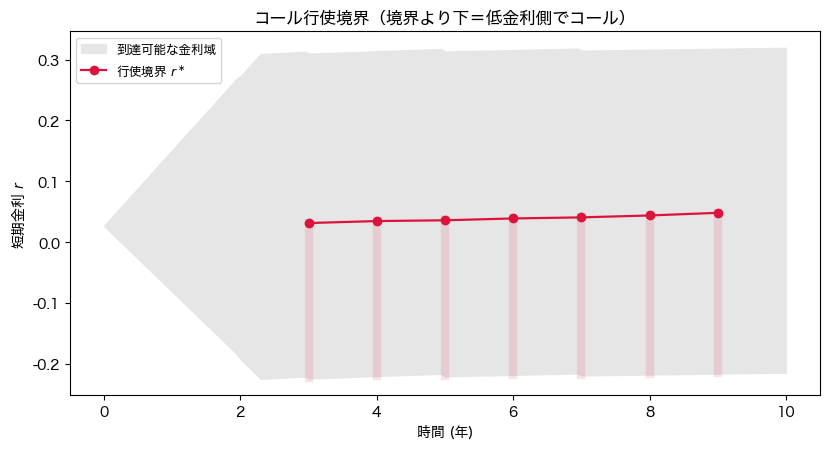

行使境界を検出したコール日数 = 7 / 7
→ 満期が近づくほど境界は上がりやすい（残存クーポンが減り、少しの金利低下でコール）。


In [6]:
def exercise_boundary(tree, bond):
    """各コール段で H と K+c が交差する短期金利 r* を線形補間で返す。"""
    _, boundary = price_on_tree(tree, bond, callable_=True, trace=True)
    out = []
    for i, t, rec in boundary:
        rec = sorted(rec)                       # j 昇順（r 昇順）
        rs = np.array([r for _, r, _, _, _ in rec])
        diff = np.array([H - Kc for _, _, H, Kc, _ in rec])  # >0 でコール（H>K+c 側）
        # diff は r 増加に対して減少（低金利ほどコール）。符号反転点を線形補間。
        rstar = np.nan
        for m in range(len(rs) - 1):
            if diff[m] > 0 >= diff[m + 1]:
                w = diff[m] / (diff[m] - diff[m + 1])
                rstar = rs[m] + w * (rs[m + 1] - rs[m])
                break
        out.append((t, rstar))
    return np.array(out)


bd = exercise_boundary(tree, bond)
reach = tree.reachable()
times_all = np.arange(tree.N + 1) * tree.dt
hi = np.array([tree.short_rate(i, reach[i][1]) for i in range(tree.N + 1)])
lo = np.array([tree.short_rate(i, reach[i][0]) for i in range(tree.N + 1)])

fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.fill_between(times_all, lo, hi, color="0.9", label="到達可能な金利域")
ax.plot(bd[:, 0], bd[:, 1], "o-", color="crimson", lw=1.6, label=r"行使境界 $r^\ast$")
# 境界より下（低金利）を薄く塗ってコール領域を示す。
for t, rstar in bd:
    if not np.isnan(rstar):
        ax.plot([t, t], [lo[int(round(t / tree.dt))], rstar], color="crimson",
                alpha=0.12, lw=6)
ax.set_xlabel("時間 (年)")
ax.set_ylabel("短期金利 $r$")
ax.set_title("コール行使境界（境界より下＝低金利側でコール）")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

valid = bd[~np.isnan(bd[:, 1].astype(float))]
print(f"行使境界を検出したコール日数 = {valid.shape[0]} / {bd.shape[0]}")
print("→ 満期が近づくほど境界は上がりやすい（残存クーポンが減り、少しの金利低下でコール）。")

## QuantLib検証

独立実装として QuantLib の `CallableFixedRateBond` と `TreeCallableFixedRateBondEngine`
に同じ Hull-White・同じカーブ・同じコール条項を渡し、自作ツリーのコーラブル債価格と
突き合わせる。あわせてストレート債も `DiscountingBondEngine` で評価し、両実装が数セント
以内で一致することを確認する。

In [7]:
import QuantLib as ql

print("QuantLib version:", ql.__version__)

today = ql.Date(1, 1, 2026)
ql.Settings.instance().evaluationDate = today
dates = [today] + [today + ql.Period(int(t), ql.Years) for t in range(1, 31)]
dfs = [1.0] + [float(curve.discount(t)) for t in range(1, 31)]
ts = ql.YieldTermStructureHandle(ql.DiscountCurve(dates, dfs, ql.Actual365Fixed()))

model = ql.HullWhite(ts, a, sigma)
engine = ql.TreeCallableFixedRateBondEngine(model, 400)

sched = ql.Schedule(today, today + ql.Period(10, ql.Years), ql.Period(ql.Annual),
                    ql.NullCalendar(), ql.Unadjusted, ql.Unadjusted,
                    ql.DateGeneration.Backward, False)
calls = ql.CallabilitySchedule()
for y in range(3, 10):
    d = today + ql.Period(y, ql.Years)
    calls.append(ql.Callability(ql.BondPrice(100.0, ql.BondPrice.Clean),
                                ql.Callability.Call, d))

ql_callable = ql.CallableFixedRateBond(0, bond.face, sched, [bond.coupon],
                                       ql.Actual365Fixed(), ql.Unadjusted, 100.0,
                                       today, calls)
ql_callable.setPricingEngine(engine)

ql_straight = ql.FixedRateBond(0, bond.face, sched, [bond.coupon],
                               ql.Actual365Fixed(), ql.Unadjusted, 100.0, today)
ql_straight.setPricingEngine(ql.DiscountingBondEngine(ts))

print(f"{'':14}{'自作ツリー':>14}{'QuantLib':>14}{'|差|':>10}")
print(f"{'ストレート債':14}{p_straight:>14.4f}{ql_straight.cleanPrice():>14.4f}"
      f"{abs(p_straight - ql_straight.cleanPrice()):>10.4f}")
print(f"{'コーラブル債':14}{p_callable:>14.4f}{ql_callable.cleanPrice():>14.4f}"
      f"{abs(p_callable - ql_callable.cleanPrice()):>10.4f}")

assert abs(p_straight - ql_straight.cleanPrice()) < 0.05
assert abs(p_callable - ql_callable.cleanPrice()) < 0.10   # 数セント以内
print("→ 自作ツリーのコーラブル債価格は QuantLib と数セント以内で一致する。")

QuantLib version: 1.42.1
                       自作ツリー      QuantLib       |差|
ストレート債              105.2285      105.2510    0.0225
コーラブル債               99.2726       99.2883    0.0158
→ 自作ツリーのコーラブル債価格は QuantLib と数セント以内で一致する。


## 実データ適用

上の合成カーブと同じ設定のコーラブル債について、(1) OAS・Zスプレッド・オプション
コストの分解、(2) 金利を $\pm100$bp 平行に動かしたときの実効デュレーションの変化
（負のコンベクシティ）を数値で確かめる。

### OAS・Zスプレッド・オプションコストの分解

「市場価格」として、モデルのフェア価格からわずかに割安な水準（フェア $-1.0$）を仮定し、
OAS とZスプレッドを逆算する。両者の差がスプレッド換算のオプションコストであり、
価格換算のオプション価値 $V_{\text{call}}$ と整合することを見る。

In [8]:
p_fair = price_on_tree(tree, bond, callable_=True)
p_mkt = p_fair - 1.0                                # 市場ではやや割安に取引と仮定

oas = solve_oas(tree, bond, p_mkt)
zspr = solve_zspread(curve, bond, p_mkt)
opt_cost = zspr - oas

# 参考：フェア価格（市場＝モデル）なら OAS≈0 で、オプションコスト≈Zスプレッド。
oas_fair = solve_oas(tree, bond, p_fair)
z_fair = solve_zspread(curve, bond, p_fair)

decomp = pd.DataFrame({
    "指標": ["Zスプレッド", "OAS", "オプションコスト（Z−OAS）"],
    "割安と仮定 (bp)": [zspr * 1e4, oas * 1e4, opt_cost * 1e4],
    "フェア価格 (bp)": [z_fair * 1e4, oas_fair * 1e4, (z_fair - oas_fair) * 1e4],
})
display(decomp)

assert opt_cost > 0                                 # コーラブルはオプションコスト正
assert abs(oas_fair) < 5.0                          # フェアなら OAS≈0（<5bp）
print(f"\nフェア価格でのオプションコスト {(z_fair - oas_fair)*1e4:.1f}bp は、"
      f"価格換算 V_call={v_call:.3f} と同じ経済実質を、スプレッドと価格の両単位で表す。")

,指標,割安と仮定 (bp),フェア価格 (bp)
0,Zスプレッド,84.409651,7.186420e+01
1,OAS,18.721739,-8.092581e-12
2,オプションコスト（Z−OAS）,65.687911,7.186420e+01



フェア価格でのオプションコスト 71.9bp は、価格換算 V_call=5.956 と同じ経済実質を、スプレッドと価格の両単位で表す。


### 金利±100bp と負のコンベクシティ

カーブを平行に動かすたびにツリーを組み直して（$\theta(t)$ を再フィット）コーラブル債・
ストレート債を再評価し、実効デュレーションと実効コンベクシティを測る。段数は再構築の
回数が多いので120段に落とす（コール日・クーポン日は段に一致）。金利水準を横に振って、
コーラブル債のデュレーションが低金利側で縮む＝負のコンベクシティを可視化する。

In [9]:
N_sweep = 120


def make_price_fn(callable_):
    """平行シフト量 → 価格 の関数を返す（毎回カーブとツリーを組み直す）。"""
    def price_fn(shift):
        c = bootstrap_par(annual, par_annual + shift, frequency=1, interp="linear_zero")
        tr = HullWhiteTree(a, sigma, c, T=Tb, n_steps=N_sweep)
        return price_on_tree(tr, bond, callable_=callable_)
    return price_fn


price_call_fn = make_price_fn(True)
price_str_fn = make_price_fn(False)

levels = np.arange(-0.02, 0.0201, 0.005)            # -200bp 〜 +200bp
dy = 0.01                                           # 実効リスクは ±100bp
rows = []
for lvl in levels:
    dc, cc = effective_risk(price_call_fn, lvl, dy)
    ds, cs = effective_risk(price_str_fn, lvl, dy)
    rows.append((lvl, price_call_fn(lvl), dc, cc, price_str_fn(lvl), ds, cs))

sweep = pd.DataFrame(rows, columns=["shift", "P_call", "Dur_call", "Conv_call",
                                    "P_str", "Dur_str", "Conv_str"])
print(sweep.assign(bp=(sweep["shift"] * 1e4).astype(int))
      [["bp", "P_call", "Dur_call", "Conv_call", "P_str", "Dur_str"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# 低金利側でコーラブル債の実効デュレーションが縮む＝負のコンベクシティ。
assert sweep["Dur_call"].iloc[0] < sweep["Dur_call"].iloc[-1]
assert (sweep["Conv_call"] < 0).any()               # どこかで負のコンベクシティ
assert (sweep["Conv_str"] > 0).all()                # ストレート債は正のコンベクシティ
print("\n→ コーラブル債は低金利側でデュレーションが縮み、実効コンベクシティが負になる。")

  bp  P_call  Dur_call  Conv_call   P_str  Dur_str
-200 108.282     3.729    -34.936 123.604    8.220
-150 106.224     4.018    -46.052 118.659    8.141
 -99 104.056     4.345    -56.681 113.958    8.062
 -49 101.710     4.698    -52.227 109.485    7.984
   0  99.239     5.071    -43.568 105.228    7.906
  50  96.666     5.427    -41.738 101.177    7.828
 100  93.991     5.762    -35.483  97.320    7.750
 150  91.219     6.068    -19.229  93.645    7.672
 200  88.409     6.333     -3.842  90.145    7.594

→ コーラブル債は低金利側でデュレーションが縮み、実効コンベクシティが負になる。


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


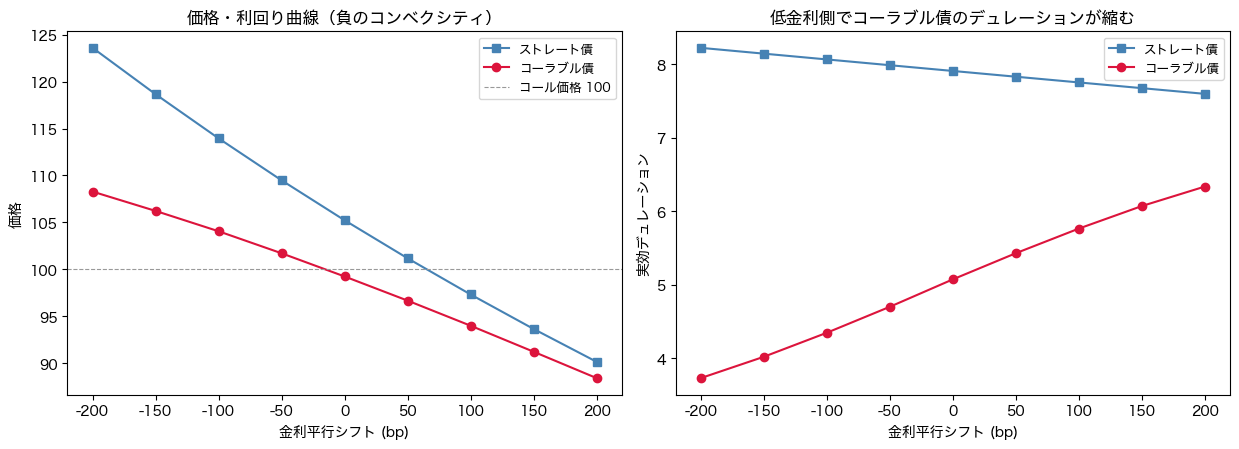

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
bp = sweep["shift"] * 1e4

# (左) 価格・利回り曲線。コーラブルは低金利側で頭打ち（上に凸）。
axes[0].plot(bp, sweep["P_str"], "s-", color="steelblue", label="ストレート債")
axes[0].plot(bp, sweep["P_call"], "o-", color="crimson", label="コーラブル債")
axes[0].axhline(bond.call_price, color="0.6", ls="--", lw=0.8, label="コール価格 100")
axes[0].set_xlabel("金利平行シフト (bp)")
axes[0].set_ylabel("価格")
axes[0].set_title("価格・利回り曲線（負のコンベクシティ）")
axes[0].legend(fontsize=9)

# (右) 実効デュレーションの水準依存。
axes[1].plot(bp, sweep["Dur_str"], "s-", color="steelblue", label="ストレート債")
axes[1].plot(bp, sweep["Dur_call"], "o-", color="crimson", label="コーラブル債")
axes[1].set_xlabel("金利平行シフト (bp)")
axes[1].set_ylabel("実効デュレーション")
axes[1].set_title("低金利側でコーラブル債のデュレーションが縮む")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### MBS との共通点

コーラブル債で見た負のコンベクシティは、MBS（mortgage-backed securities、住宅ローン
担保証券）でそのまま再現する。住宅ローンの借り手は、金利が下がると低金利ローンへ
借り換える（期限前償還する）権利を持つ。これは発行体のコール権と経済的に同じで、
投資家はプールの借り手にオプションを売っている。金利が下がると期限前償還が増えて
元本が早く返り、値上がり益が頭打ちになる——コーラブル債がコールされて価格が $K$ で
抑えられるのと同型である。

実務上の含意も共通する。第一に、リスクは実効デュレーション・実効コンベクシティで測る
しかない（キャッシュフローが金利に依存するため解析デュレーションが使えない）。第二に、
相対価値は OAS で比較する（単純利回りやZスプレッドはオプションの重さを混ぜてしまう）。
第三に、金利低下局面でデュレーションが縮む「ネガティブ・コンベクシティ・ヘッジ」の
動学が、両者に共通のリスク管理課題として現れる。違いは、MBS のオプションが多数の
借り手の行動の集計で、行使が最適解から系統的にずれる（プリペイメントモデルが要る）点で、
コーラブル債の「発行体が最適にコールする」よりも境界がぼやける。

## 演習

1. **金利±100bpでの実効デュレーションのネガコン。** 本編と同じコーラブル債について、
   クーポンを $\{4\%, 5\%, 6\%\}$ の3通りに変えたうえで、金利平行シフト $-200$bp〜
   $+200$bp（$25$bp刻み）でコーラブル債の価格と実効デュレーション（$\pm100$bp 中心差分）を
   求め、水準に対してプロットせよ。クーポンが高いほど負のコンベクシティが強く出る
   （オプションがイン・ザ・マネーになりやすい）ことを、デュレーションの落ち込み幅で
   説明せよ。
2. **OAS・Zスプレッド・オプションコストの分解表。** 本編のコーラブル債について、市場
   価格をフェア価格から $\{+1.0, 0.0, -1.0, -2.0\}$ ずらした4通り仮定し、各ケースで
   OAS・Zスプレッド・オプションコスト（Z−OAS）を逆算して表にまとめよ。市場価格が下がる
   （割安になる）と OAS が上がる一方、オプションコストはどう動くかを述べ、オプション
   コストが主にボラティリティ $\sigma$ とクーポン水準で決まる（市場価格の水準では大きく
   動かない）ことを数値で確認せよ。

解答例は `solutions/S6/sol_0604.py` に置く。

## 用語集

定義の正は `glossary/06_derivatives.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| コーラブル債 | callable bond | 発行体が定価で買い戻せる債券。ストレート債−コールオプション |
| OAS | option-adjusted spread | オプションを織り込んだうえでモデル価格を市場価格に合わせる一定スプレッド |
| 後退帰納法 | backward induction | 満期から時間をさかのぼり、各節点で継続価値と行使価値を比較して評価する手続き |
| Zスプレッド | zero-volatility spread | オプションを無視し約定CFを割り引いて市場価格に一致させる一定スプレッド |
| 行使境界 | exercise boundary | 継続価値とコール価格が入れ替わる金利水準。これより低金利でコールされる |